# tablas


In [3]:
# ============================================================
# GENERADOR DE TABLAS ACADÉMICAS EN PDF Y SVG
# Para Word / Tesis / Paper
# ============================================================

# Instalar dependencias si hace falta:
# pip install pandas matplotlib reportlab svglib

import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from reportlab.platypus import (
    SimpleDocTemplate,
    Table,
    TableStyle,
    Paragraph,
    Spacer
)

from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.pagesizes import letter

# ============================================================
# CONFIGURACIÓN GENERAL
# ============================================================

OUTPUT_DIR = Path("./output_tablas")
OUTPUT_DIR.mkdir(exist_ok=True)

# ============================================================
# TABLA 1
# DIAGNÓSTICO DE INSTRUMENTOS
# ============================================================

df_diag = pd.DataFrame({

    "Ecuación": [
        "Consumo",
        "Inversión",
        "Exportac. netas"
    ],

    "Endógenas": [
        "labsh, z",
        "h, z",
        "labsh, z"
    ],

    "Instrumentos excluidos": [

        "UD_s, lsal_min, hc,\nL.labsh, L.z",

        "lusa, lxr, hc,\nL.h, L.z",

        "UD_s, lsal_min, hc,\nL.labsh, L.z,\noil_rents,\nL.oil_rents"
    ],

    "F-test exclusión": [

        "50.50 (0.000)\n/ 3.12 (0.023)",

        "42.75 (0.000)\n/ 20.95 (0.000)",

        "43.58 (0.000)\n/ 2.92 (0.030)"
    ],

    "Shea R² parcial": [
        "0.834 / 0.389",
        "0.743 / 0.356",
        "0.772 / 0.486"
    ],

    "Test endogeneidad\n(p-valor)": [
        "0.0306",
        "0.0026",
        "0.3115"
    ],

    "Test overid\n(p-valor)": [
        "0.2817",
        "0.0159",
        "0.3806"
    ]

})

# ============================================================
# TABLA 2
# RESULTADOS 2SLS
# ============================================================

df_2sls = pd.DataFrame({

    "Variable": [

        "labsh",
        "h (profit share)",
        "z (ciclo)",
        "r_real",
        "emp",
        "d_k",
        "oil_rents",
        "lxr",
        "lusa",
        "_cons",
        "Observaciones",
        "R²",
        "Wald chi²"
    ],

    "csh_c (consumo)": [

        "0.5978*** (0.2231)",
        "—",
        "0.3695** (0.1873)",
        "-0.0002 (0.0006)",
        "-0.0019*** (0.0005)",
        "—",
        "—",
        "—",
        "—",
        "0.5722*** (0.0820)",
        "27",
        "0.6114",
        "59.75 (0.0000)"
    ],

    "csh_i (inversión)": [

        "—",
        "0.5561*** (0.1921)",
        "1.1716*** (0.3503)",
        "-0.0002* (0.0001)",
        "—",
        "-1.6387 (1.1256)",
        "-0.0027 (0.0019)",
        "—",
        "—",
        "-0.1189 (0.1328)",
        "37",
        "0.1026",
        "59.95 (0.0000)"
    ],

    "nx (exportaciones netas)": [

        "-0.8536* (0.4581)",
        "—",
        "0.6701 (0.5585)",
        "—",
        "—",
        "—",
        "—",
        "-0.0059 (0.0176)",
        "0.5393*** (0.0670)",
        "-8.2241*** (1.0654)",
        "26",
        "0.9315",
        "412.94 (0.0000)"
    ]

})

# ============================================================
# TABLA 3
# VARIABLES Y FUENTES
# ============================================================

df_vars = pd.DataFrame({

    "Variable": [

        "labsh",
        "h",
        "csh_c",
        "csh_i",
        "nx",
        "z",
        "r_real",
        "emp",
        "d_k",
        "oil_rents",
        "lxr",
        "lusa",
        "UD_s",
        "hc",
        "sal_min"

    ],

    "Descripción": [

        "Participación salarial en el ingreso",
        "Participación de beneficios",
        "Participación del consumo privado en el PIB",
        "Participación de la inversión privada en el PIB",
        "Exportaciones netas / PIB",
        "Componente cíclico del PIB",
        "Tasa de interés real ex post",
        "Tasa de empleo",
        "Crecimiento del stock de capital",
        "Rentas petroleras / PIB",
        "Log del tipo de cambio real",
        "Log del PIB real de EE.UU.",
        "Utilización de capacidad instalada",
        "Capital humano",
        "Salario mínimo real"

    ],

    "Fuente": [

        "PWT 10.0",
        "Calculada",
        "PWT 10.0",
        "PWT 10.0",
        "Calculada",
        "HP Filter",
        "Banxico",
        "INEGI",
        "PWT 10.0",
        "Banco Mundial",
        "PWT 10.0",
        "FMI / WEO",
        "INEGI",
        "PWT 10.0",
        "Banxico"

    ],

    "Periodicidad": [
        "Anual"
    ] * 15

})

# ============================================================
# FUNCIÓN PARA EXPORTAR SVG
# ============================================================

def save_svg_table(df, filename, title):

    fig, ax = plt.subplots(
        figsize=(15, 0.65 * len(df) + 2)
    )

    ax.axis("off")

    table = ax.table(

        cellText=df.values,
        colLabels=df.columns,

        loc="center",

        cellLoc="center"

    )

    table.auto_set_font_size(False)
    table.set_fontsize(8)

    table.scale(1, 1.5)

    plt.title(
        title,
        fontsize=14,
        pad=20
    )

    filepath = OUTPUT_DIR / filename

    plt.savefig(
        filepath,
        format="svg",
        bbox_inches="tight"
    )

    plt.close()

    print(f"SVG guardado: {filepath}")


# ============================================================
# GENERAR SVGs
# ============================================================

save_svg_table(
    df_diag,
    "tabla_diagnosticos.svg",
    "Tabla 1. Diagnóstico de Instrumentos"
)

save_svg_table(
    df_2sls,
    "tabla_2sls.svg",
    "Tabla 2. Estimaciones 2SLS"
)

save_svg_table(
    df_vars,
    "tabla_variables.svg",
    "Tabla 3. Variables y Fuentes"
)

# ============================================================
# FUNCIÓN PARA TABLAS PDF
# ============================================================

styles = getSampleStyleSheet()

def add_pdf_table(elements, df, title):

    elements.append(
        Paragraph(
            f"<b>{title}</b>",
            styles["Heading2"]
        )
    )

    data = [list(df.columns)] + df.values.tolist()

    table = Table(
        data,
        repeatRows=1
    )

    table.setStyle(TableStyle([

        ('BACKGROUND', (0, 0), (-1, 0), colors.lightgrey),

        ('TEXTCOLOR', (0, 0), (-1, 0), colors.black),

        ('GRID', (0, 0), (-1, -1), 0.5, colors.black),

        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),

        ('FONTSIZE', (0, 0), (-1, -1), 8),

        ('BOTTOMPADDING', (0, 0), (-1, 0), 8),

        ('VALIGN', (0, 0), (-1, -1), 'MIDDLE')

    ]))

    elements.append(table)

    elements.append(
        Spacer(1, 15)
    )

# ============================================================
# GENERAR PDF
# ============================================================

pdf_path = OUTPUT_DIR / "tablas_metodologia.pdf"

doc = SimpleDocTemplate(

    str(pdf_path),

    pagesize=letter

)

elements = []

add_pdf_table(
    elements,
    df_diag,
    "Tabla 1. Diagnóstico de Instrumentos"
)

add_pdf_table(
    elements,
    df_2sls,
    "Tabla 2. Estimaciones 2SLS"
)

add_pdf_table(
    elements,
    df_vars,
    "Tabla 3. Variables, Fuentes y Periodicidad"
)

doc.build(elements)

print("\n===================================")
print("ARCHIVOS GENERADOS")
print("===================================")
print(f"PDF: {pdf_path}")

print("\nSVG:")
print("- tabla_diagnosticos.svg")
print("- tabla_2sls.svg")
print("- tabla_variables.svg")
print("===================================")

SVG guardado: output_tablas/tabla_diagnosticos.svg
SVG guardado: output_tablas/tabla_2sls.svg
SVG guardado: output_tablas/tabla_variables.svg

ARCHIVOS GENERADOS
PDF: output_tablas/tablas_metodologia.pdf

SVG:
- tabla_diagnosticos.svg
- tabla_2sls.svg
- tabla_variables.svg


# Resultados 

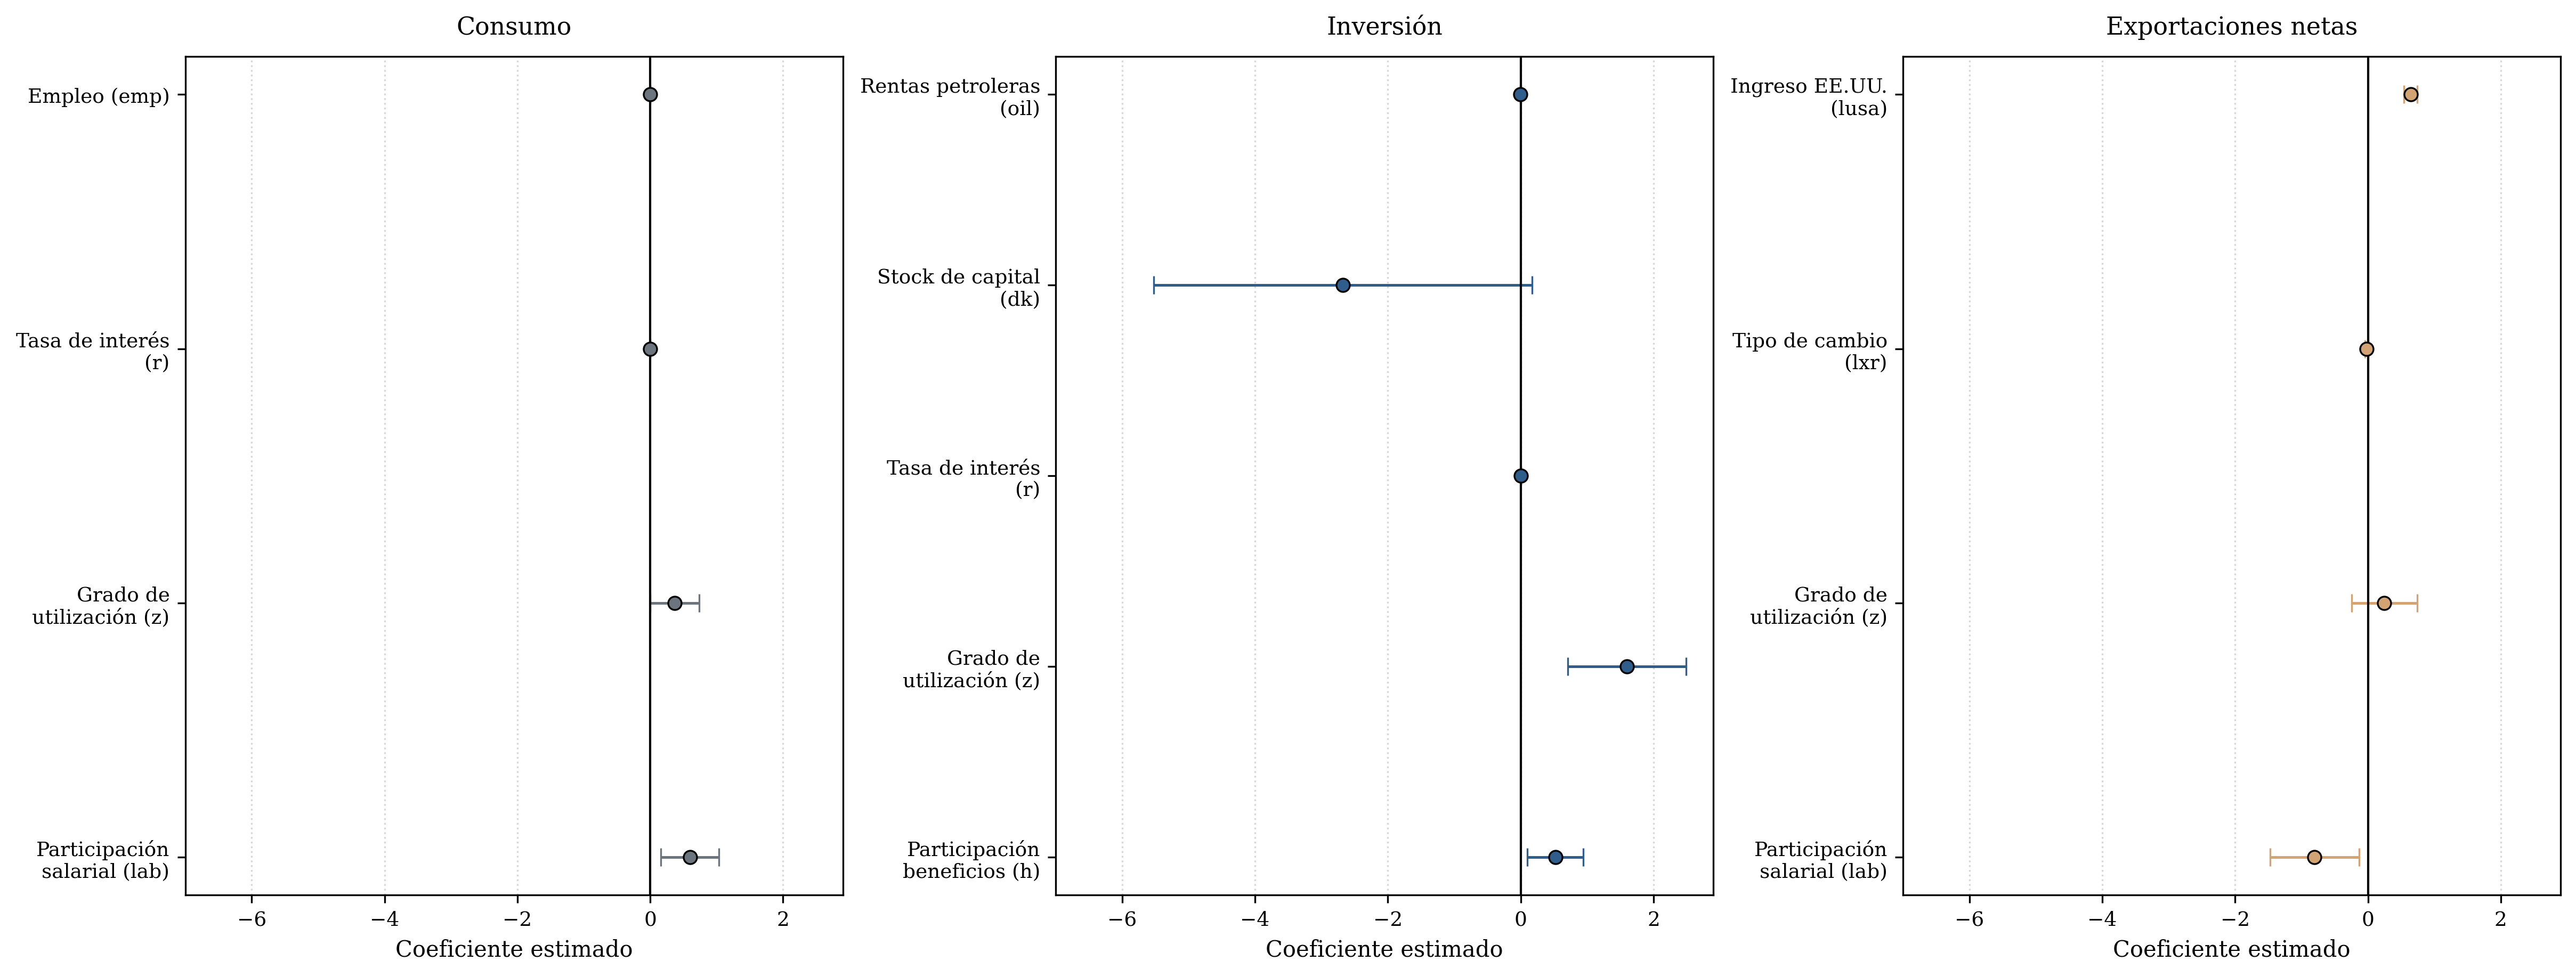

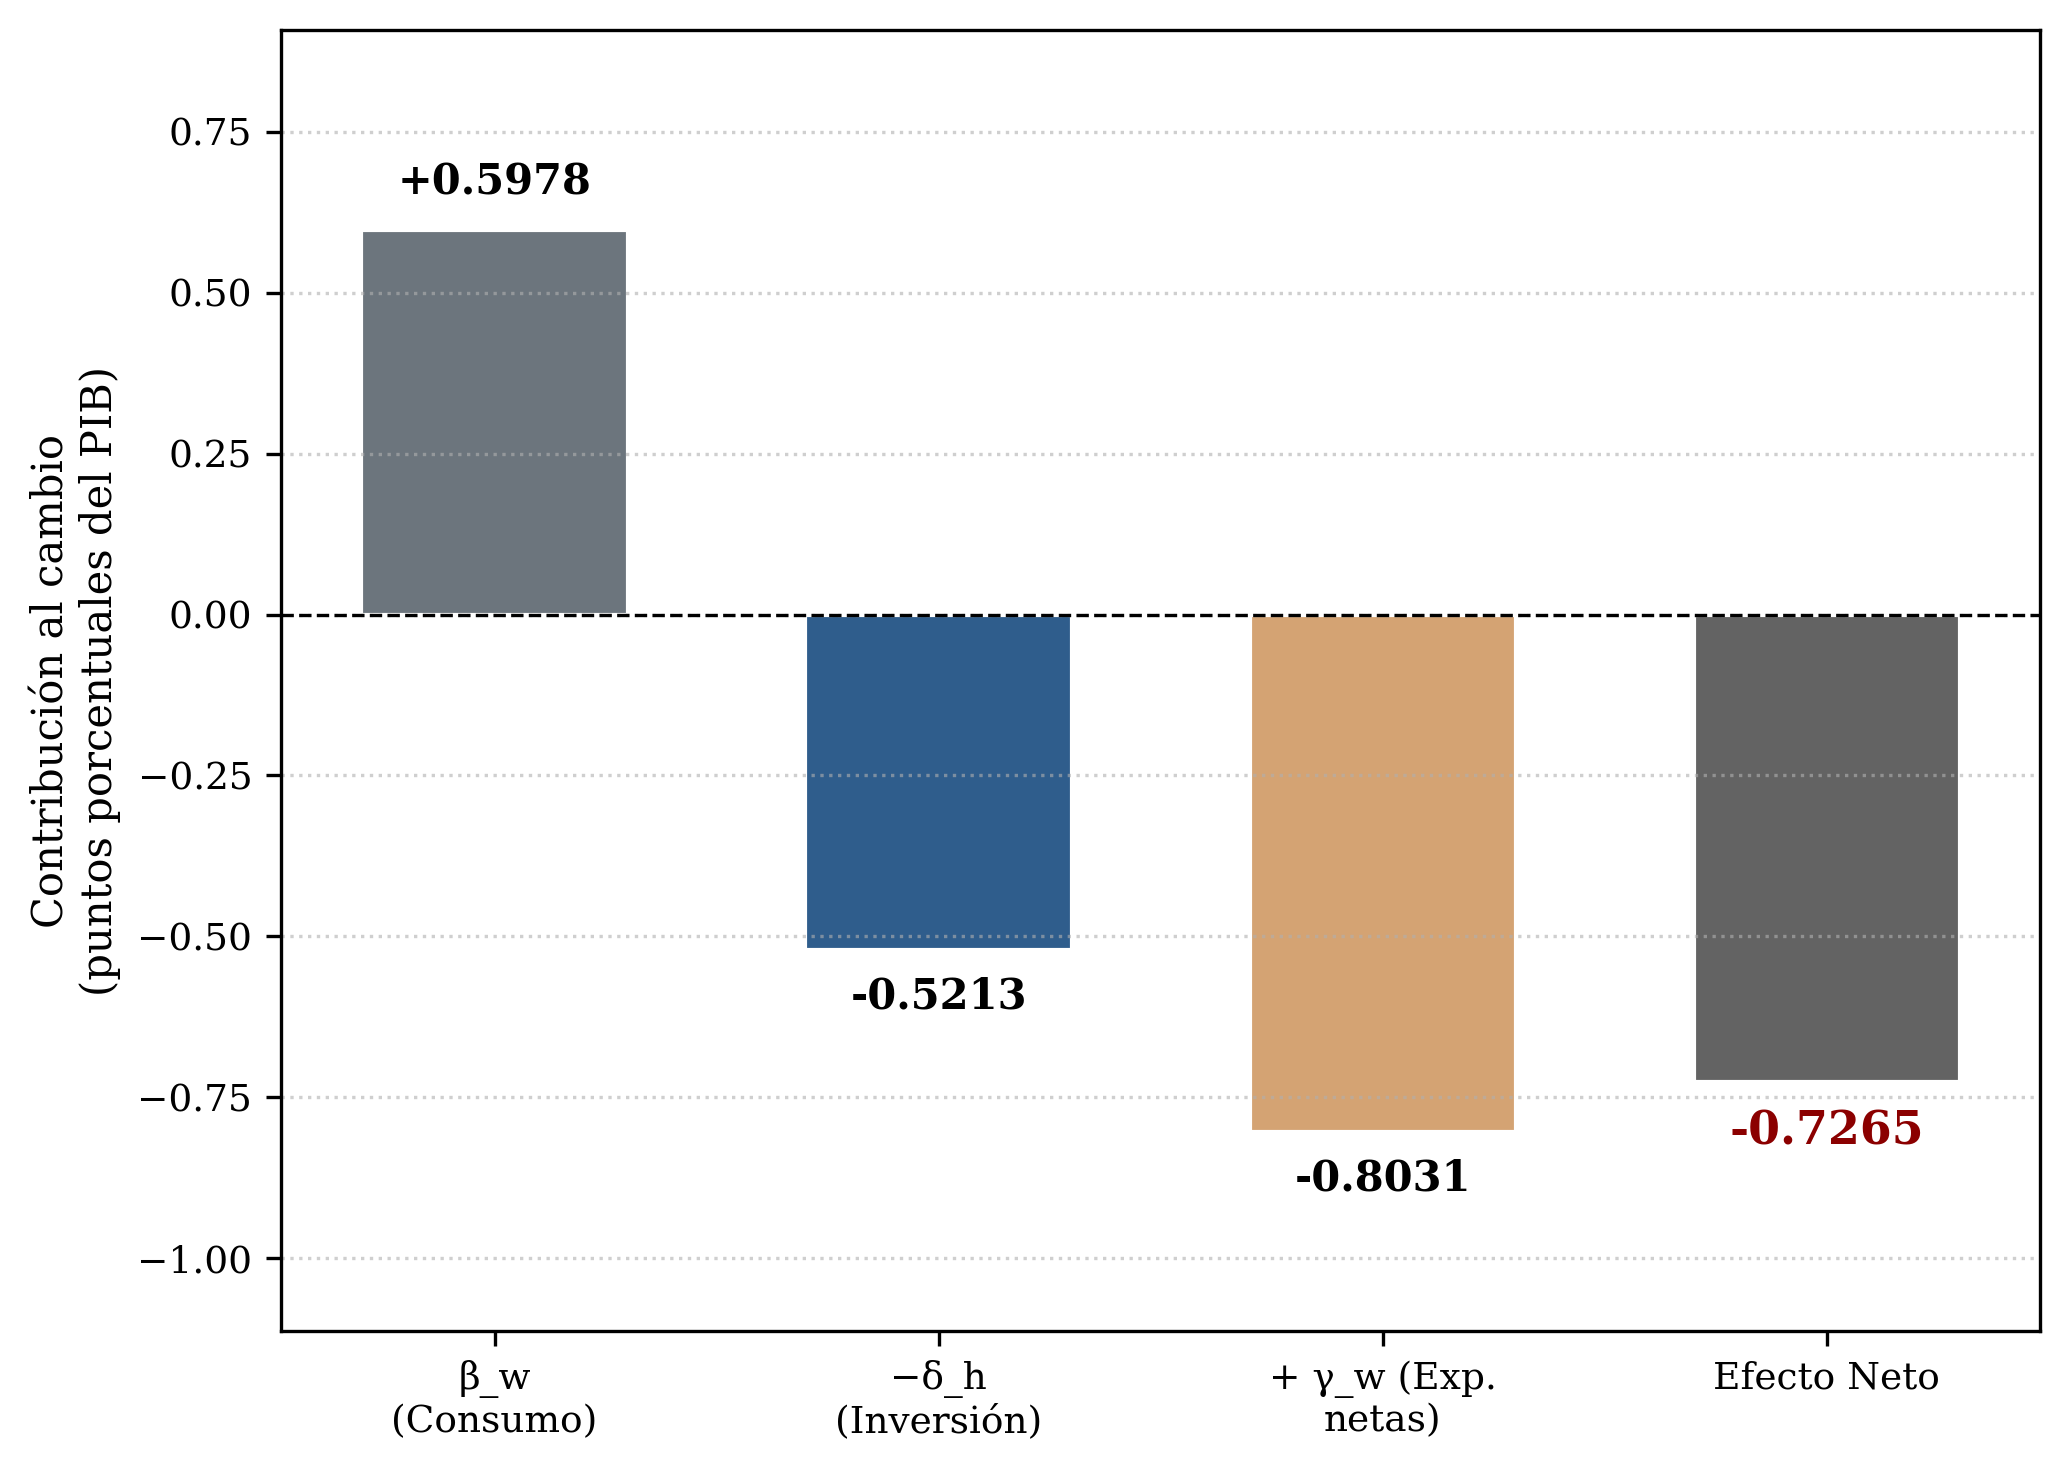

Efecto neto wage-led/profit-led: -0.7265


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import textwrap

# =====================================================
# ESTILO ACADÉMICO UNIFICADO (TIPO REVISTA)
# =====================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 300
})

# =====================================================
# DATOS ACTUALIZADOS (NUEVOS RESULTADOS)
# =====================================================
modelos = ['Consumo', 'Inversión', 'Exportaciones netas']

coefs = {
    'Consumo': {
        'lab_t':  (0.5978, 0.2231, '***'),
        'z_t':    (0.3695, 0.1873, '**'),
        'r_t':    (-0.0002, 0.0006, ''),
        'emp_t':  (-0.0019, 0.0005, '***'),
        'const':  (0.5722, 0.0, '***')
    },

    'Inversión': {
        'h_t':    (0.5213, 0.2149, '**'),
        'z_t':    (1.5990, 0.4551, '***'),
        'r_t':    (-0.0003, 0.0002, ''),
        'dk_t':   (-2.6754, 1.4539, '*'),
        'oil rents_t': (-0.0025, 0.0022, ''),
        'const':  (-0.0706, 0.0, '')
    },

    'Exportaciones netas': {
        'lab_t':  (-0.8031, 0.3407, '**'),
        'z_t':    (0.2479, 0.2512, ''),
        'lxr_t':  (-0.0225, 0.0132, '*'),
        'lusa_t': (0.6419, 0.0526, '***'),
        'const':  (-9.9082, 0.0, '***')
    }
}

# =====================================================
# ORDEN Y ETIQUETAS
# =====================================================
var_orden = [
    'lab_t', 'h_t', 'z_t', 'r_t',
    'emp_t', 'dk_t', 'oil rents_t',
    'lxr_t', 'lusa_t'
]

var_labels = {
    'lab_t': 'Participación\nsalarial (lab)',
    'h_t':   'Participación\nbeneficios (h)',
    'z_t':   'Grado de\nutilización (z)',
    'r_t':   'Tasa de interés\n(r)',
    'emp_t': 'Empleo\n(emp)',
    'dk_t':  'Stock de capital\n(dk)',
    'oil rents_t': 'Rentas\npetroleras (oil)',
    'lxr_t': 'Tipo de cambio\n(lxr)',
    'lusa_t':'Ingreso EE.UU.\n(lusa)'
}

# =====================================================
# COLORES
# =====================================================
colores_modelo = {
    'Consumo':             '#6C757D',
    'Inversión':           '#2F5D8C',
    'Exportaciones netas': '#D4A373'
}

# =====================================================
# FUNCIÓN PARA INTERVALOS DE CONFIANZA
# =====================================================
def compute_ci(coef, se):
    return 1.96 * se  # IC ~95%

# =====================================================
# FIGURA 1: FOREST PLOT
# =====================================================
fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 6),
    constrained_layout=True
)

# Límites globales eje X
all_ci = []

for mod in modelos:
    for v in coefs[mod]:
        eff, se, _ = coefs[mod][v]

        if se != 0:
            ci = compute_ci(eff, se)
            all_ci.extend([eff - ci, eff + ci])
        else:
            all_ci.append(eff)

x_min = -7
x_max = np.ceil(max(all_ci) * 1.15 * 10) / 10

for mod, ax in zip(modelos, axes):

    vars_mod = [v for v in var_orden if v in coefs[mod]]

    y_pos = np.arange(len(vars_mod))

    effects = []
    ci_vals = []

    for v in vars_mod:

        eff, se, sig = coefs[mod][v]

        effects.append(eff)

        if se != 0:
            ci_vals.append(compute_ci(eff, se))
        else:
            ci_vals.append(0)

    color = colores_modelo[mod]

    ax.errorbar(
        effects,
        y_pos,
        xerr=ci_vals,
        fmt='o',
        color=color,
        markerfacecolor=color,
        markeredgecolor='black',
        markeredgewidth=0.8,
        capsize=4,
        elinewidth=1.2,
        capthick=1.2
    )

    ax.axvline(0, color='black', linewidth=1)

    ax.set_xlim(x_min, x_max)

    ax.set_yticks(y_pos)

    ax.set_yticklabels([
        textwrap.fill(var_labels[v], width=18)
        for v in vars_mod
    ])

    ax.set_title(mod, pad=10)

    ax.set_xlabel('Coeficiente estimado')

    ax.grid(axis='x', linestyle=':', alpha=0.5)

    ax.locator_params(axis='x', nbins=6)

plt.savefig(
    'coeficientes_forest_plot.pdf',
    bbox_inches='tight'
)

plt.savefig(
    'coeficientes_forest_plot.svg',
    bbox_inches='tight'
)

plt.show()

# =====================================================
# FIGURA 2: EFECTO NETO
# =====================================================
beta_w  =  0.5978146
delta_h =  0.5212579
gamma_w = -0.8030845

componentes = [
    'β_w (Consumo)',
    '−δ_h (Inversión)',
    '+ γ_w (Exp. netas)',
    'Efecto Neto'
]

valores_acum = [
    beta_w,
    -delta_h,
    gamma_w
]

total = sum(valores_acum)

# Límites dinámicos eje Y
y_min_vals = min(valores_acum + [total])
y_max_vals = max(valores_acum + [total])

margen = 0.15 * (y_max_vals - y_min_vals) + 0.1

y_lim_bajo = y_min_vals - margen
y_lim_alto = y_max_vals + margen

fig, ax = plt.subplots(figsize=(7, 5))

x_pos = np.arange(4)

# Barras componentes
ax.bar(
    x_pos[:-1],
    valores_acum,
    color=[
        colores_modelo['Consumo'],
        colores_modelo['Inversión'],
        colores_modelo['Exportaciones netas']
    ],
    edgecolor='white',
    width=0.6
)

# Barra efecto neto
ax.bar(
    x_pos[-1],
    total,
    color='#636363',
    edgecolor='white',
    width=0.6
)

ax.axhline(
    0,
    color='black',
    linewidth=0.8,
    linestyle='--'
)

# Etiquetas numéricas
for pos, val in zip(x_pos[:-1], valores_acum):

    ax.text(
        pos,
        val + (0.04 if val >= 0 else -0.04),
        f'{val:+.4f}',
        ha='center',
        va='bottom' if val >= 0 else 'top',
        fontweight='bold',
        fontsize=10
    )

ax.text(
    x_pos[-1],
    total + (0.04 if total >= 0 else -0.04),
    f'{total:+.4f}',
    ha='center',
    va='bottom' if total >= 0 else 'top',
    fontweight='bold',
    fontsize=11,
    color='darkred'
)

ax.set_xticks(x_pos)

ax.set_xticklabels([
    textwrap.fill(c, width=12)
    for c in componentes
])

ax.set_ylabel(
    'Contribución al cambio\n(puntos porcentuales del PIB)'
)

ax.grid(axis='y', linestyle=':', alpha=0.6)

ax.set_ylim(y_lim_bajo, y_lim_alto)

plt.tight_layout()

plt.savefig(
    'efecto_neto_waterfall.pdf',
    bbox_inches='tight'
)

plt.savefig(
    'efecto_neto_waterfall.svg',
    bbox_inches='tight'
)

plt.show()

# =====================================================
# EFECTO NETO FINAL
# =====================================================
print(f"Efecto neto wage-led/profit-led: {total:.4f}")